In [ ]:
from test_sturm_liouville_solver_steady import *
import math

In [101]:
N = [32]
DIM = len(N)
L = [1.0] * DIM 

In [102]:
TEST_BC = [0, 1, 2]
TEST_MODE = [0, min(N)//4, min(N)//2, min(N)-1, min(N), min(N)+1]

In [ ]:
def get_mode(bc_from, bc_to, spectrum, threshold):
    """
    bc = 0: periodic (two-sided spectrum)
    bc != 0: non-periodic (one-sided spectrum)

    spectrum: 1D array
    threshold: amplitude threshold (relative to max)
    """
    spectrum = np.asarray(spectrum)
    N = spectrum.size

    amp = np.abs(spectrum)
    mask = amp >= threshold

    idx = np.where(mask)[0]

    modes = []

    if bc_from == 0:
        # periodic: two-sided FFT indexing
        for k in idx:
            if k <= N // 2:
                mode = k
            else:
                mode = k - N   # negative frequencies
            modes.append(mode)
    elif bc_from == bc_to and bc_from == 1:
        modes = (idx + 1).tolist()
    else:
        modes = idx.tolist()

    # 去重 + 排序
    modes = sorted(set(modes))

    return modes

通过 get_mode 函数, 用户可以知道如何查看 sturm_liouville_solver 谱空间结果
1. 计算结果是 corner zero
2. 周期性边界条件的结果是双边谱, 其他边界条件是单边谱 

- test-7 分析  
在纯 dirichlet 边界条件下($f(0)=f(L)=0$)，其内部的波动必须正负抵消, 因此 DC 分量必须是 0

- test-25 分析   
在纯 neumann 边界条件下(边界法向导数为0)，如果源项（Source Term）的均值不为零， 此时与高斯散度定理相违背，泊松方程在数学上是无解的。  
解决方法:  
1. Source Term 减去均值, 表示假设有一个虚拟的 Source Term 抵消机制使得系统稳定  
2. 引入吸收项, 将泊松方程转化成亥姆霍兹方程


------------------------
* test-1
    boundary condition : from period to period
    mode               : 0
    actual mode        : [0]
    Result             : [PASSED] Sampling theorem satisfied.


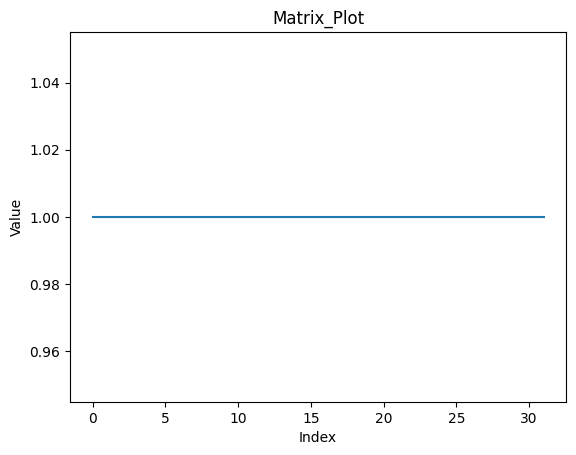

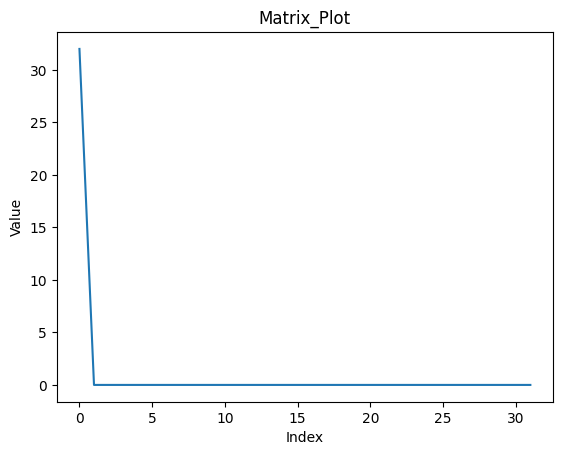


------------------------
* test-2
    boundary condition : from period to period
    mode               : 8
    actual mode        : [-8, 8]
    Result             : [PASSED] Sampling theorem satisfied.


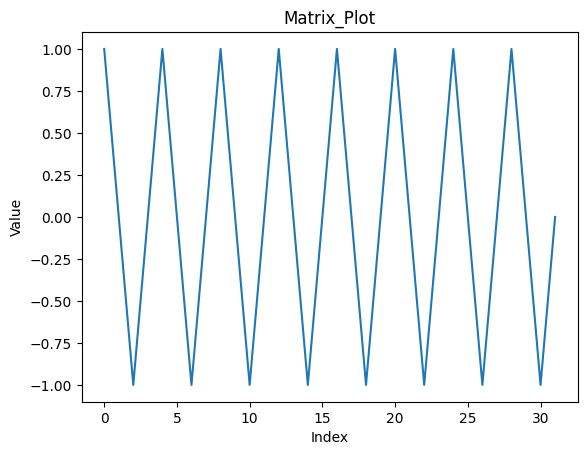

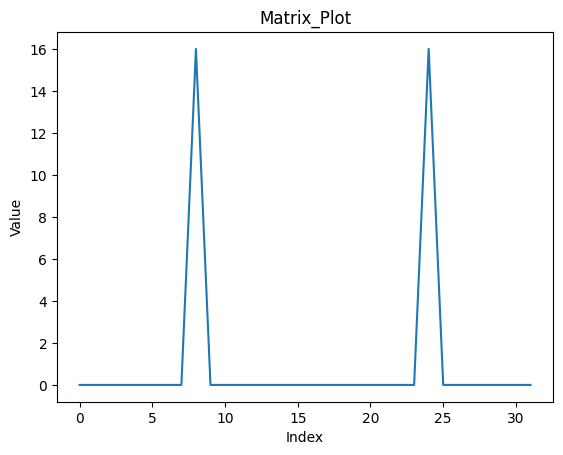


------------------------
* test-3
    boundary condition : from period to period
    mode               : 16
    actual mode        : [16]
    Result             : [PASSED] Sampling theorem satisfied.


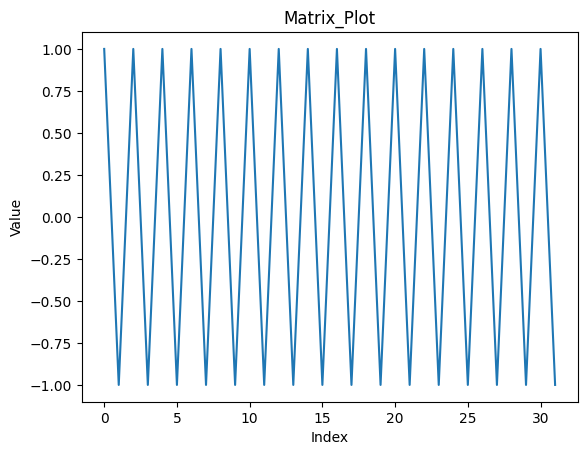

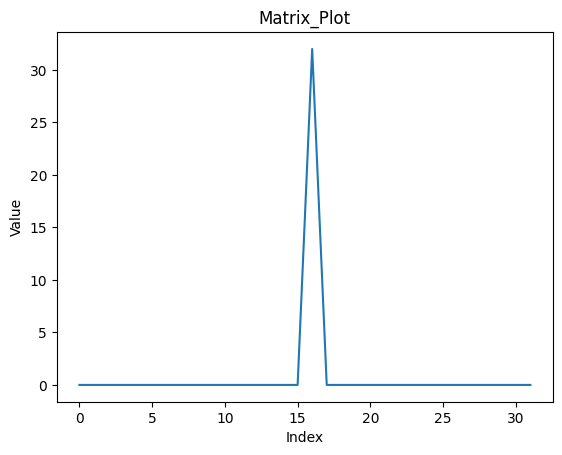


------------------------
* test-4
    boundary condition : from period to period
    mode               : 31
    actual mode        : [-1, 1]
    Result             : [FAILED] Resolution N might be too low.


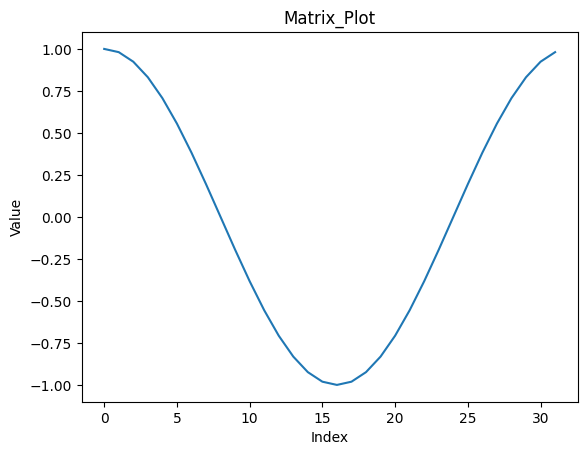

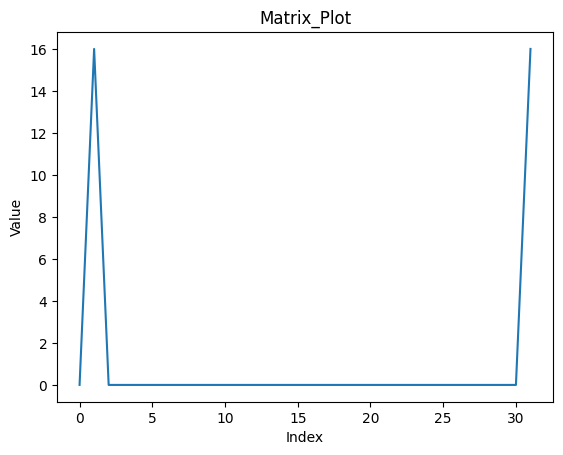


------------------------
* test-5
    boundary condition : from period to period
    mode               : 32
    actual mode        : [0]
    Result             : [FAILED] Resolution N might be too low.


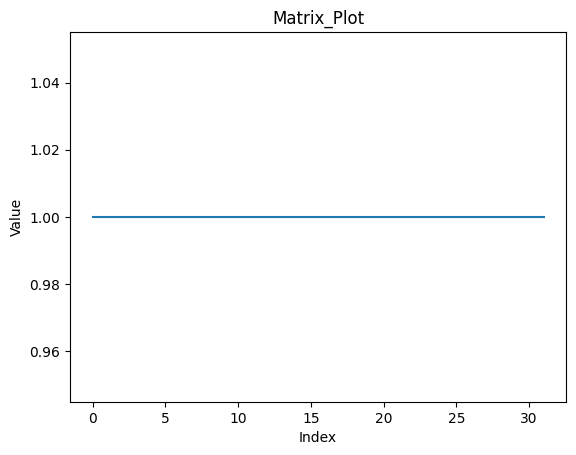

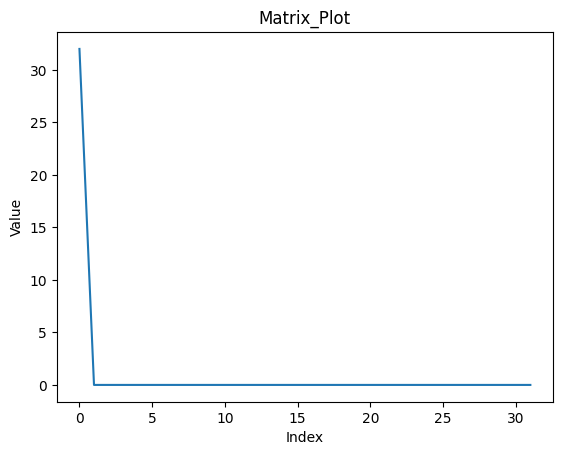


------------------------
* test-6
    boundary condition : from period to period
    mode               : 33
    actual mode        : [-1, 1]
    Result             : [FAILED] Resolution N might be too low.


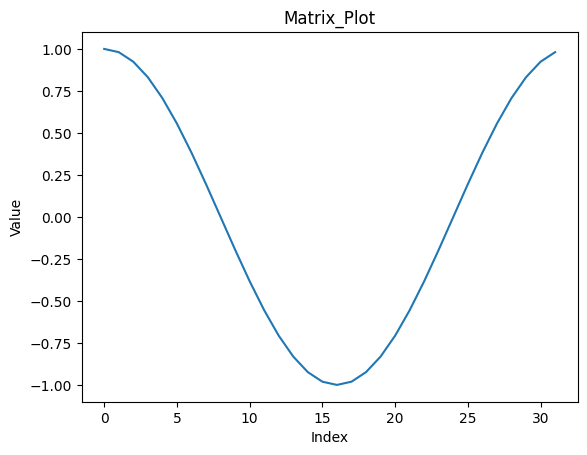

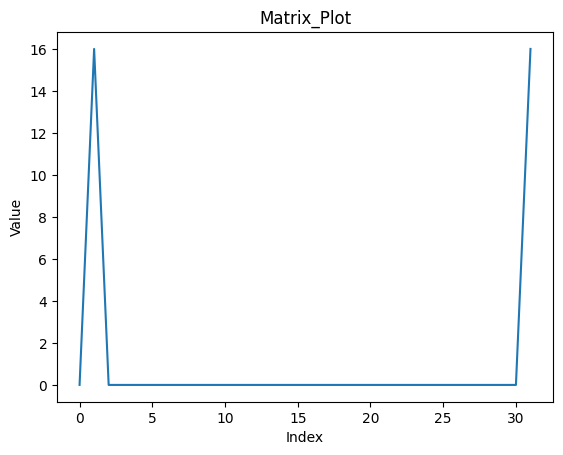


------------------------
* test-7
    boundary condition : from dirichlet to dirichlet
    mode               : 0
    actual mode        : []
    Result             : [FAILED] Resolution N might be too low.


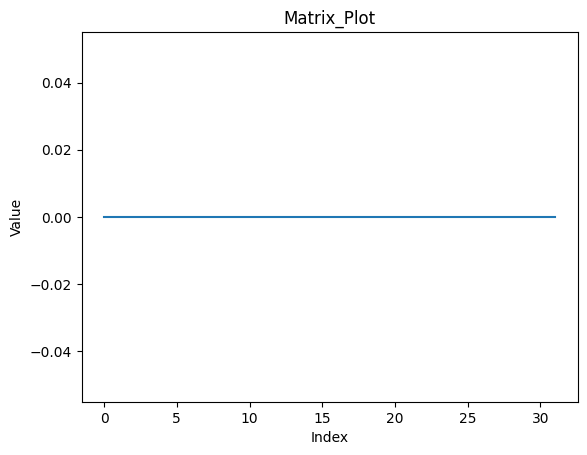

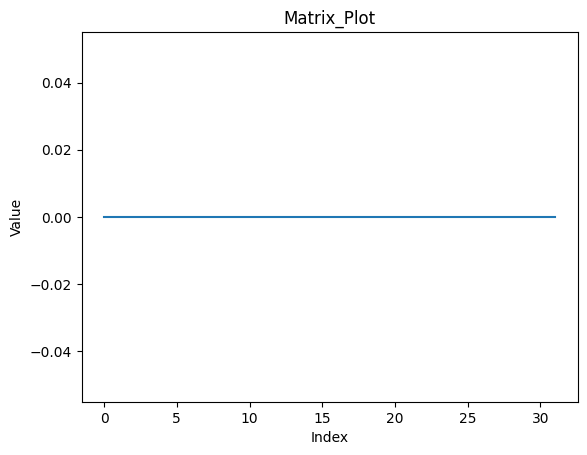


------------------------
* test-8
    boundary condition : from dirichlet to dirichlet
    mode               : 8
    actual mode        : [8]
    Result             : [PASSED] Sampling theorem satisfied.


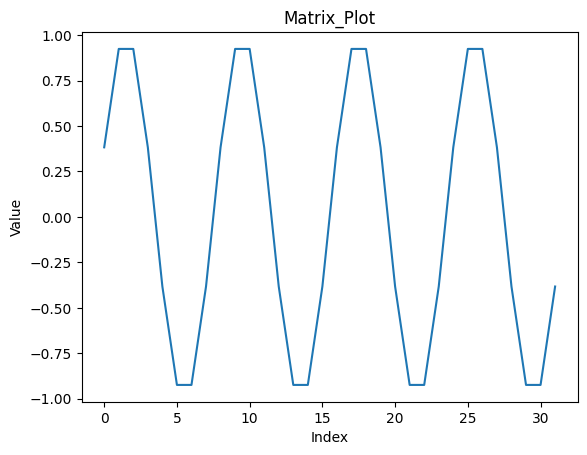

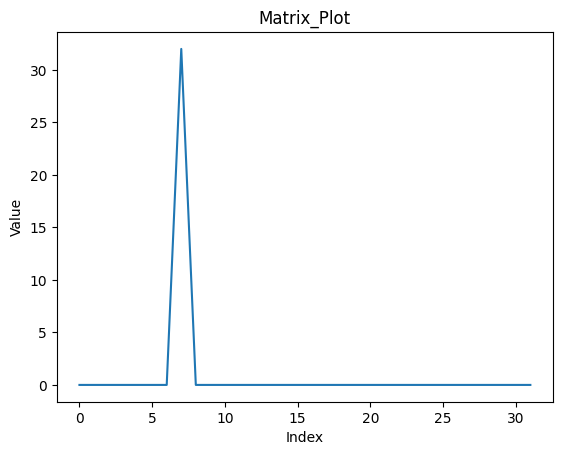


------------------------
* test-9
    boundary condition : from dirichlet to dirichlet
    mode               : 16
    actual mode        : [16]
    Result             : [PASSED] Sampling theorem satisfied.


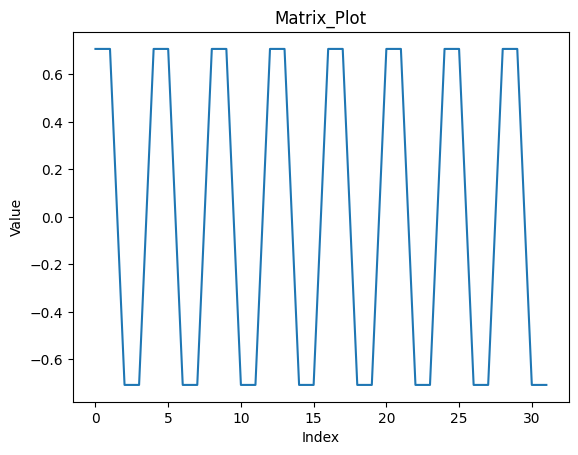

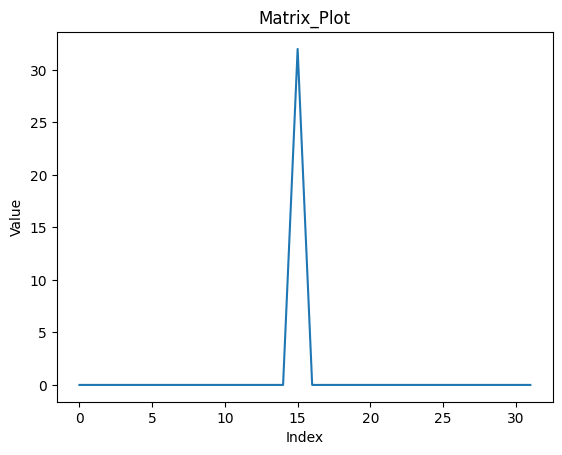


------------------------
* test-10
    boundary condition : from dirichlet to dirichlet
    mode               : 31
    actual mode        : [31]
    Result             : [PASSED] Sampling theorem satisfied.


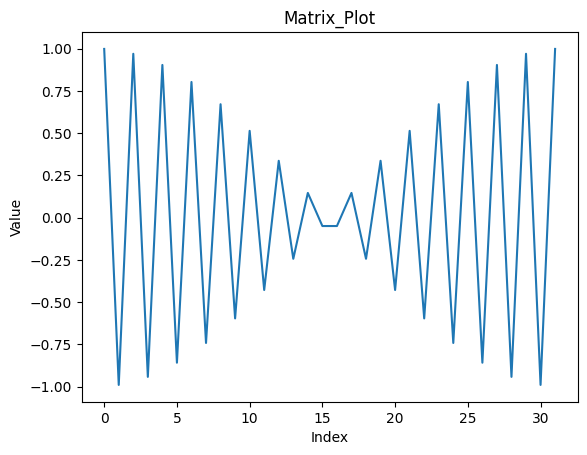

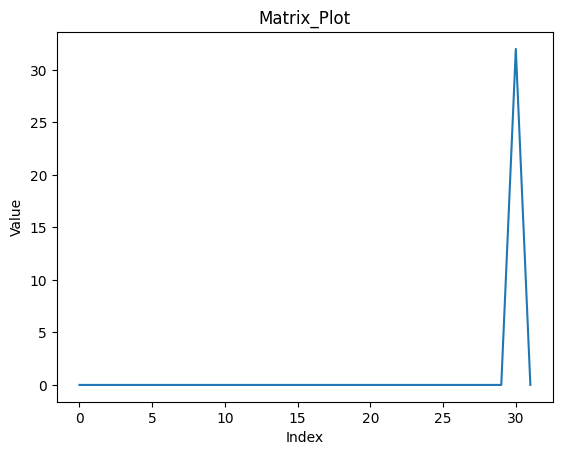


------------------------
* test-11
    boundary condition : from dirichlet to dirichlet
    mode               : 32
    actual mode        : [32]
    Result             : [PASSED] Sampling theorem satisfied.


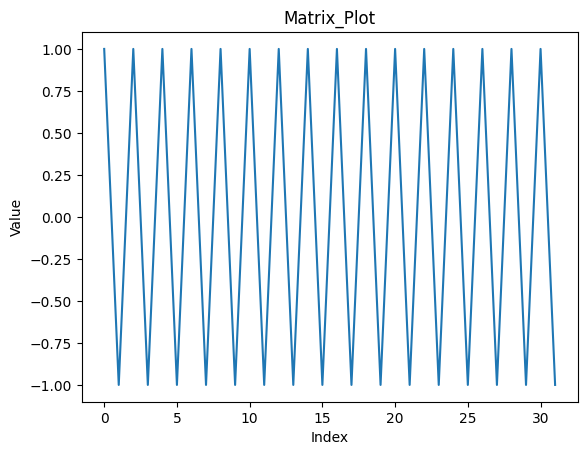

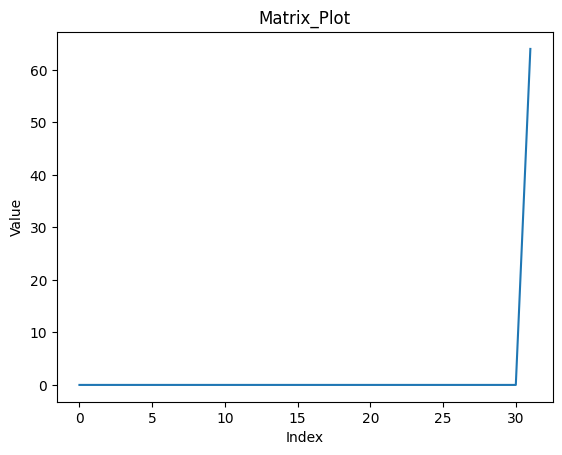


------------------------
* test-12
    boundary condition : from dirichlet to dirichlet
    mode               : 33
    actual mode        : [31]
    Result             : [FAILED] Resolution N might be too low.


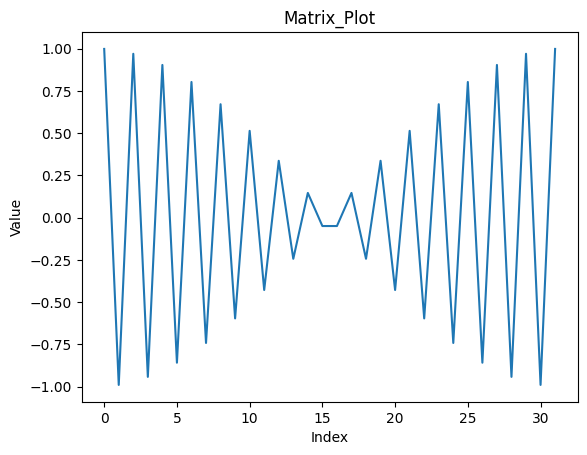

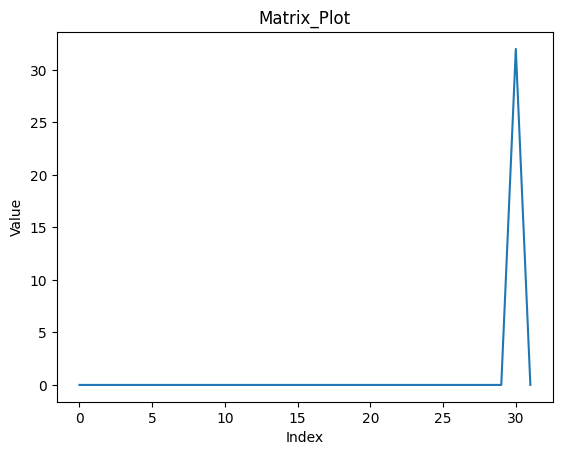


------------------------
* test-13
    boundary condition : from dirichlet to neumann
    mode               : 0
    actual mode        : [0]
    Result             : [PASSED] Sampling theorem satisfied.


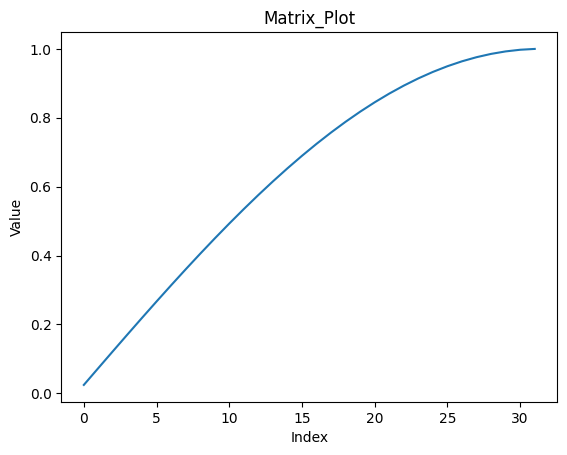

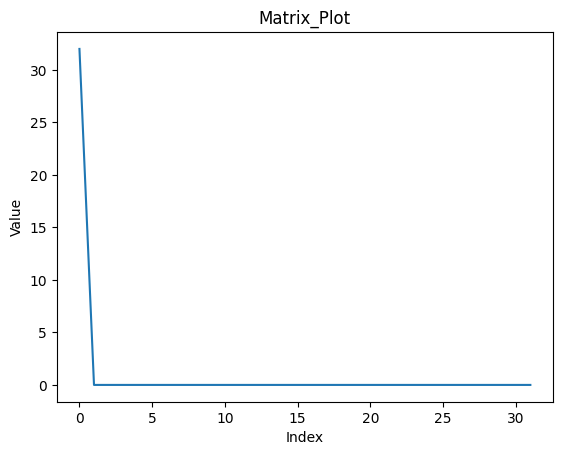


------------------------
* test-14
    boundary condition : from dirichlet to neumann
    mode               : 8
    actual mode        : [8]
    Result             : [PASSED] Sampling theorem satisfied.


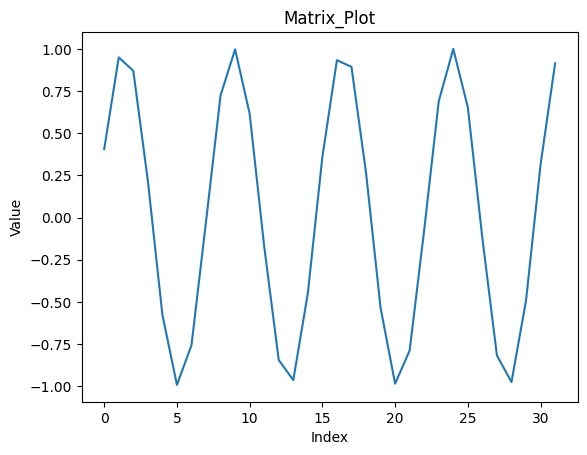

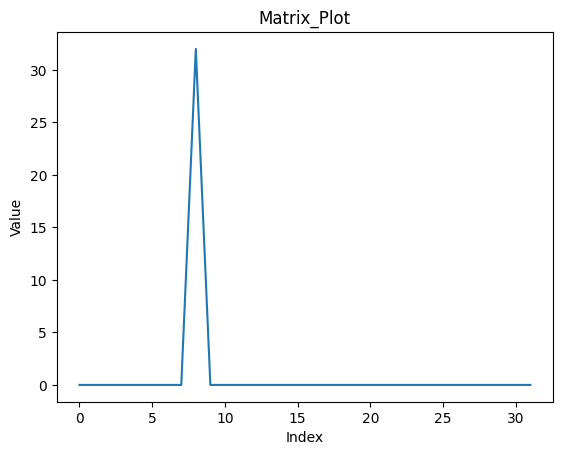


------------------------
* test-15
    boundary condition : from dirichlet to neumann
    mode               : 16
    actual mode        : [16]
    Result             : [PASSED] Sampling theorem satisfied.


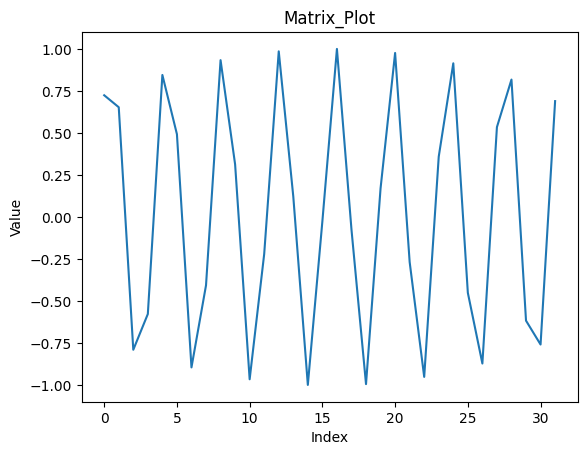

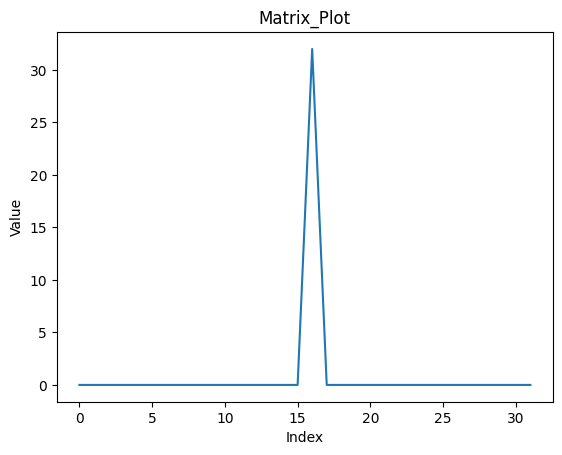


------------------------
* test-16
    boundary condition : from dirichlet to neumann
    mode               : 31
    actual mode        : [31]
    Result             : [PASSED] Sampling theorem satisfied.


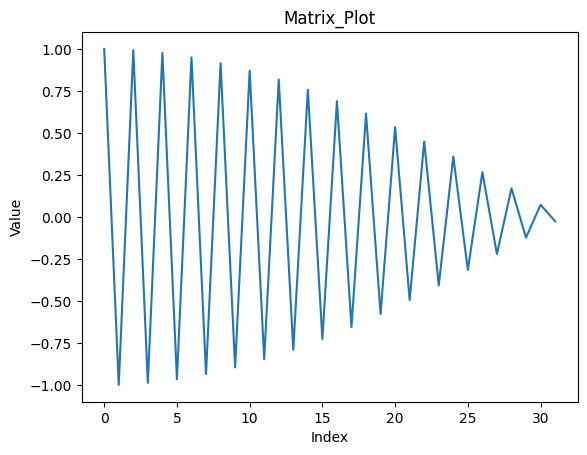

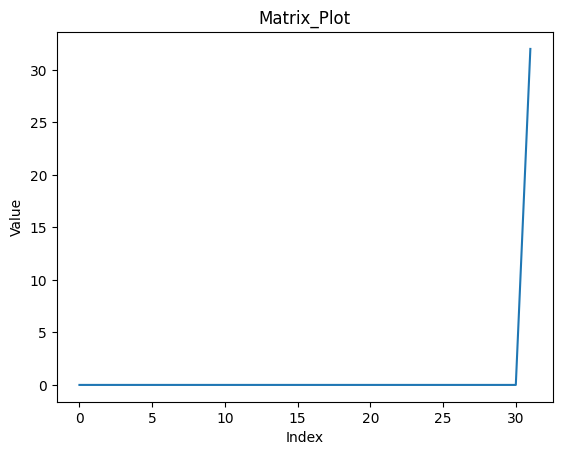


------------------------
* test-17
    boundary condition : from dirichlet to neumann
    mode               : 32
    actual mode        : [31]
    Result             : [FAILED] Resolution N might be too low.


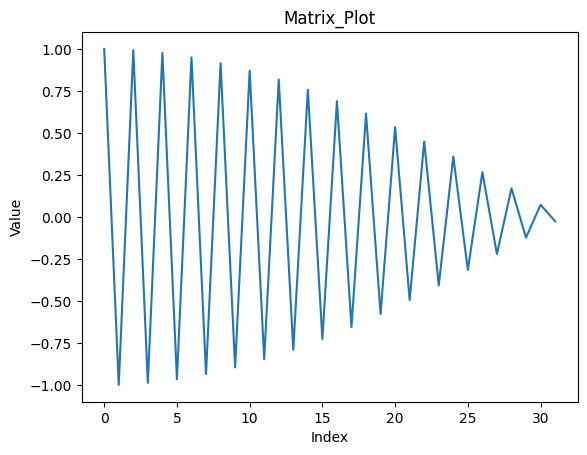

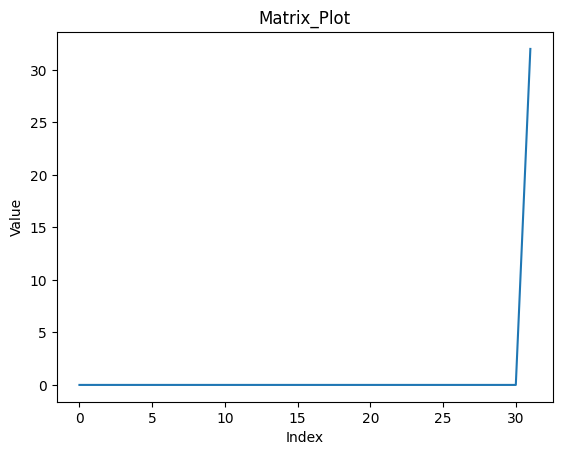


------------------------
* test-18
    boundary condition : from dirichlet to neumann
    mode               : 33
    actual mode        : [30]
    Result             : [FAILED] Resolution N might be too low.


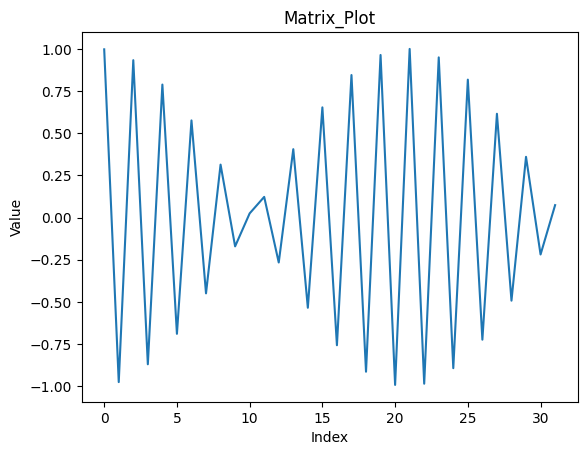

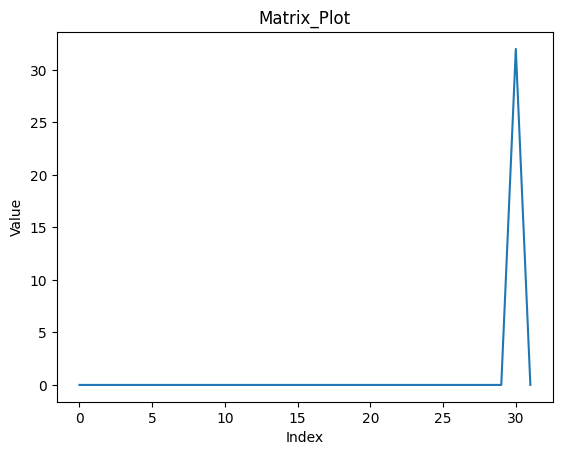


------------------------
* test-19
    boundary condition : from neumann to dirichlet
    mode               : 0
    actual mode        : [0]
    Result             : [PASSED] Sampling theorem satisfied.


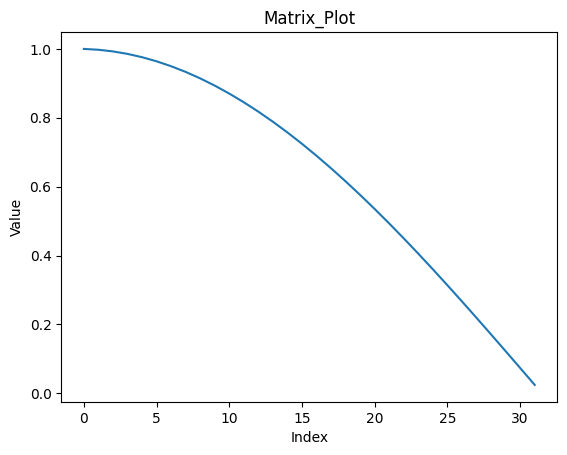

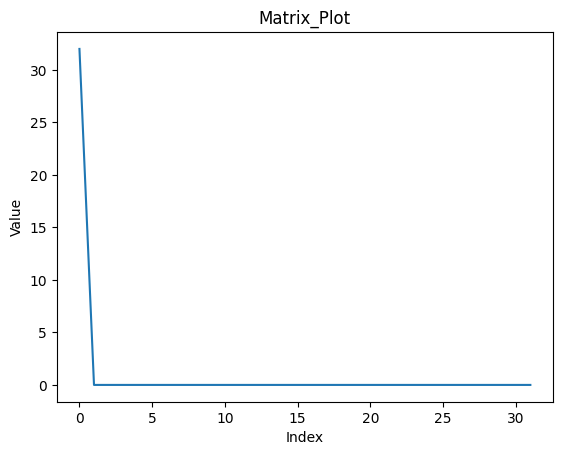


------------------------
* test-20
    boundary condition : from neumann to dirichlet
    mode               : 8
    actual mode        : [8]
    Result             : [PASSED] Sampling theorem satisfied.


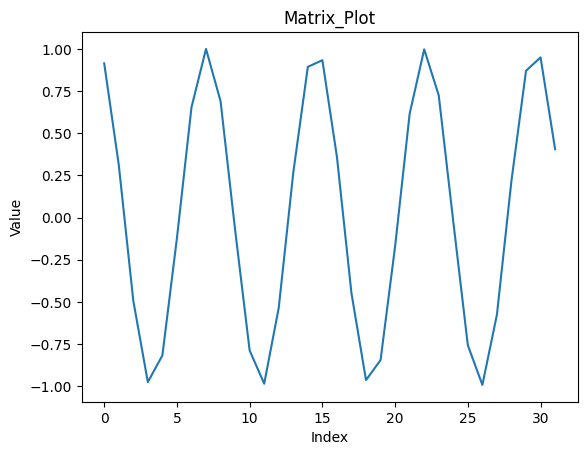

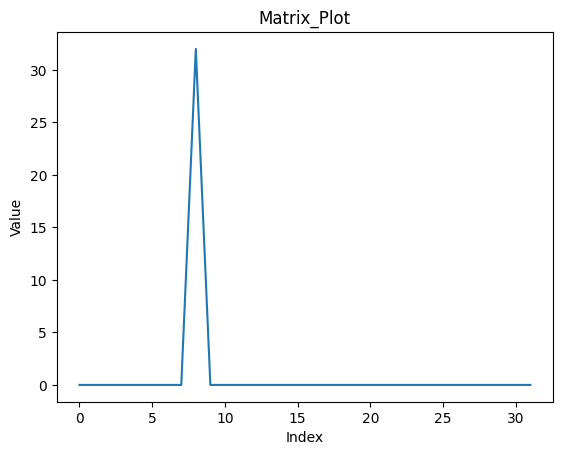


------------------------
* test-21
    boundary condition : from neumann to dirichlet
    mode               : 16
    actual mode        : [16]
    Result             : [PASSED] Sampling theorem satisfied.


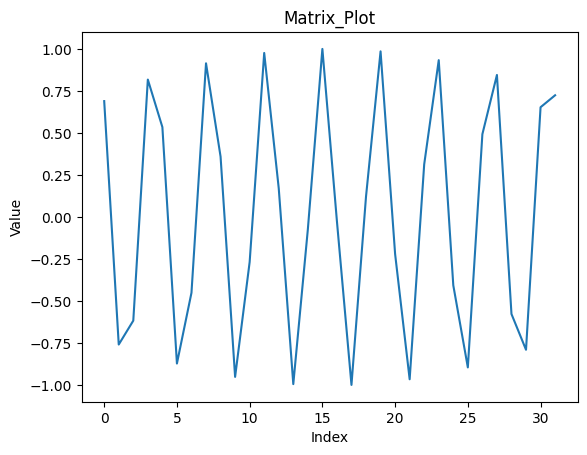

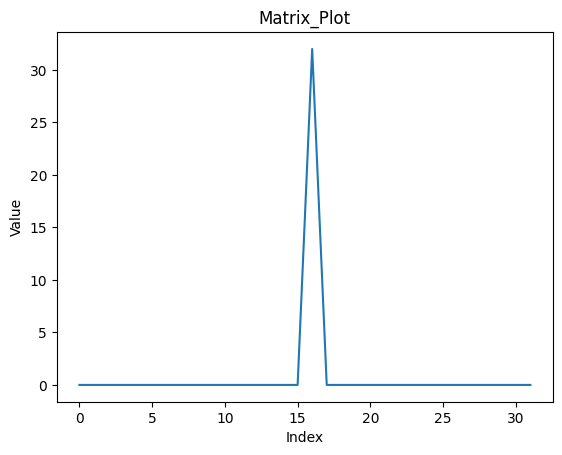


------------------------
* test-22
    boundary condition : from neumann to dirichlet
    mode               : 31
    actual mode        : [31]
    Result             : [PASSED] Sampling theorem satisfied.


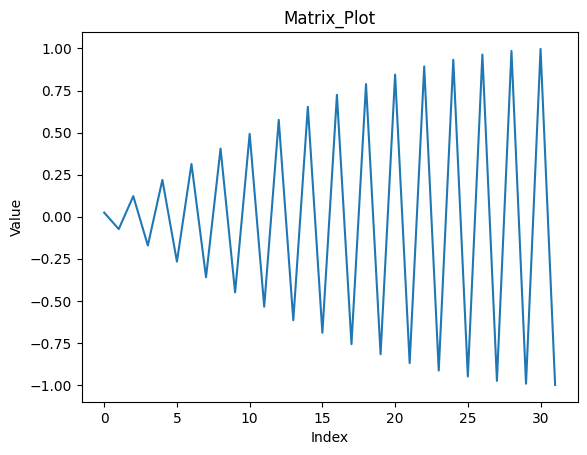

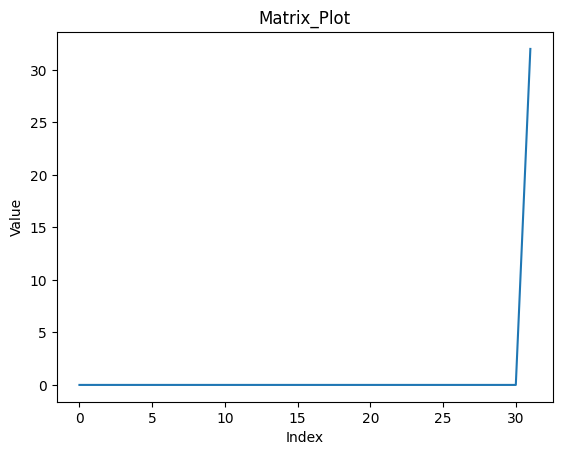


------------------------
* test-23
    boundary condition : from neumann to dirichlet
    mode               : 32
    actual mode        : [31]
    Result             : [FAILED] Resolution N might be too low.


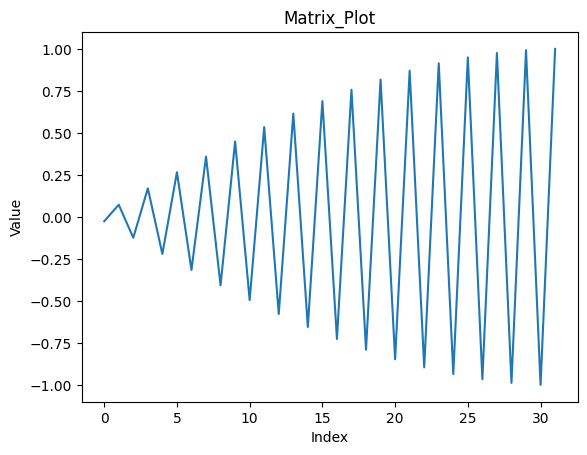

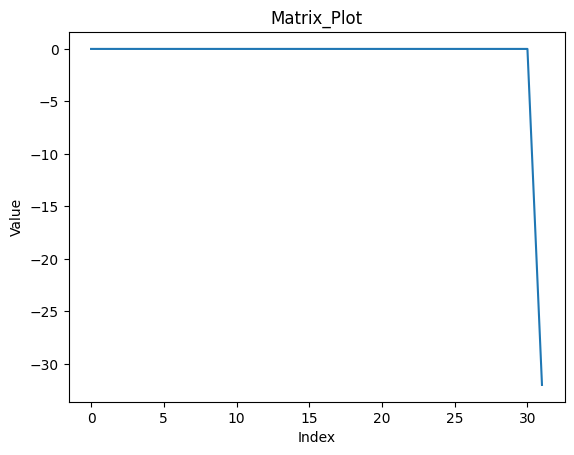


------------------------
* test-24
    boundary condition : from neumann to dirichlet
    mode               : 33
    actual mode        : [30]
    Result             : [FAILED] Resolution N might be too low.


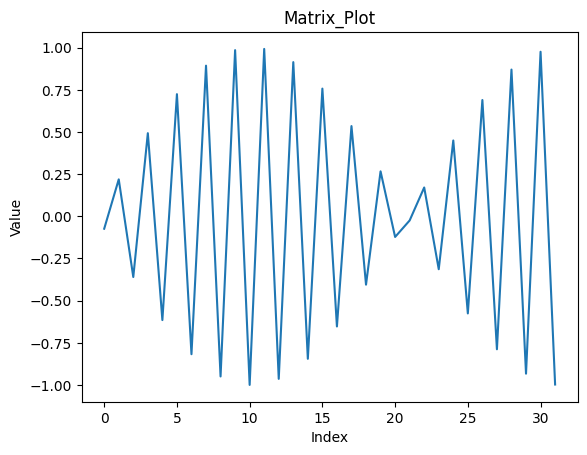

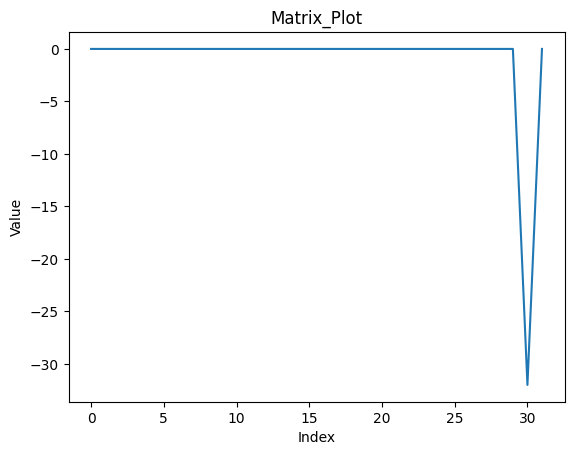


------------------------
* test-25
    boundary condition : from neumann to neumann
    mode               : 0
    actual mode        : [0]
    Result             : [PASSED] Sampling theorem satisfied.


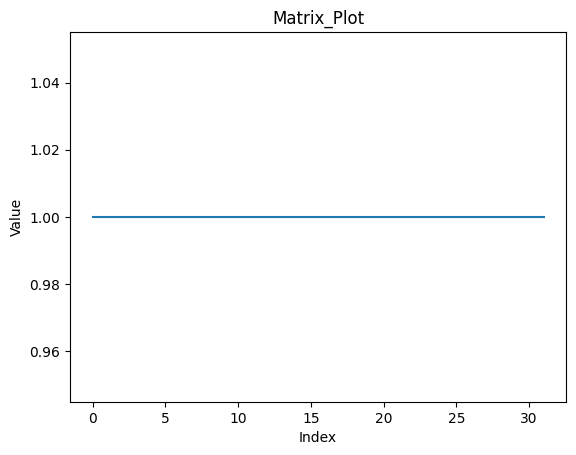

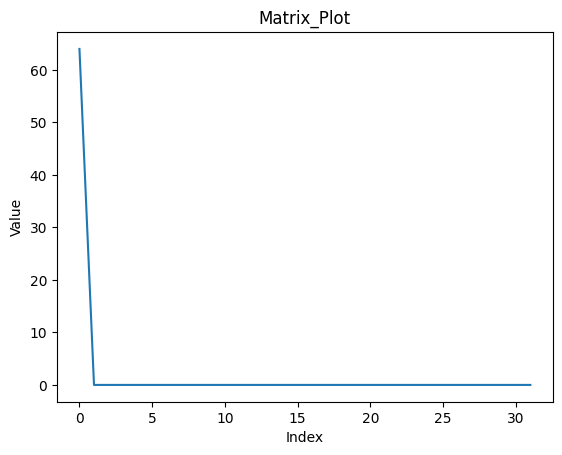


------------------------
* test-26
    boundary condition : from neumann to neumann
    mode               : 8
    actual mode        : [8]
    Result             : [PASSED] Sampling theorem satisfied.


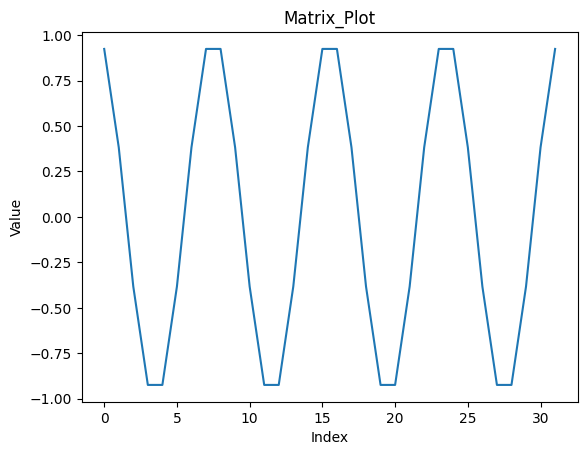

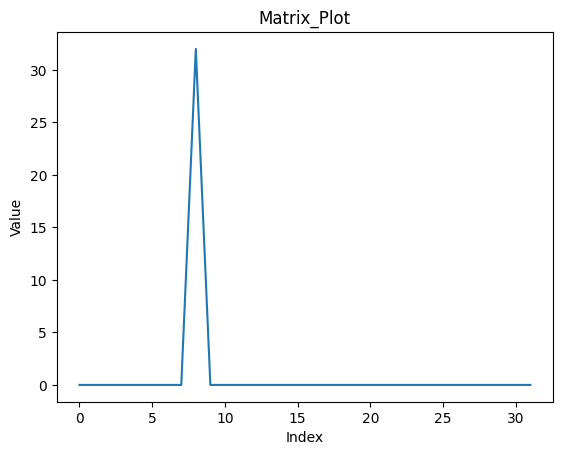


------------------------
* test-27
    boundary condition : from neumann to neumann
    mode               : 16
    actual mode        : [16]
    Result             : [PASSED] Sampling theorem satisfied.


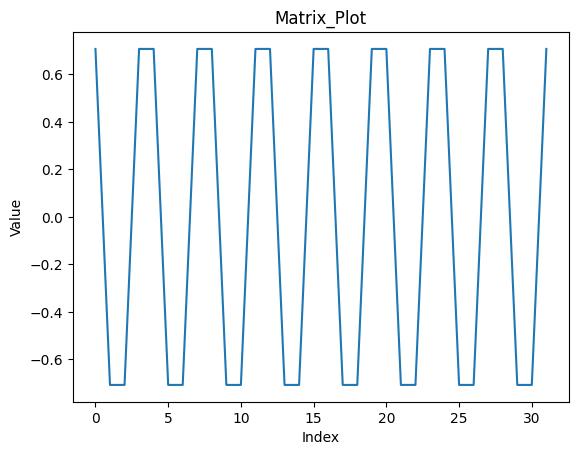

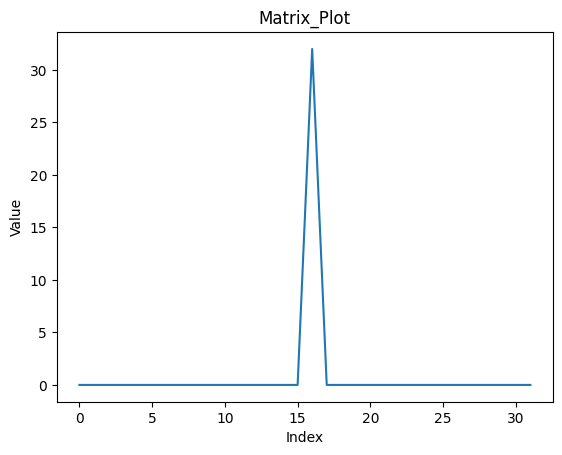


------------------------
* test-28
    boundary condition : from neumann to neumann
    mode               : 31
    actual mode        : [31]
    Result             : [PASSED] Sampling theorem satisfied.


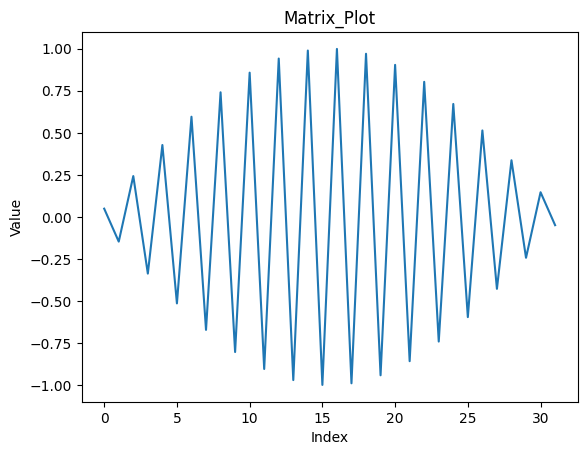

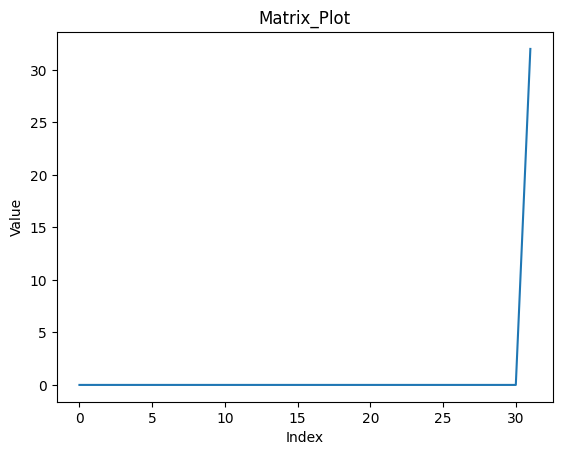


------------------------
* test-29
    boundary condition : from neumann to neumann
    mode               : 32
    actual mode        : []
    Result             : [FAILED] Resolution N might be too low.


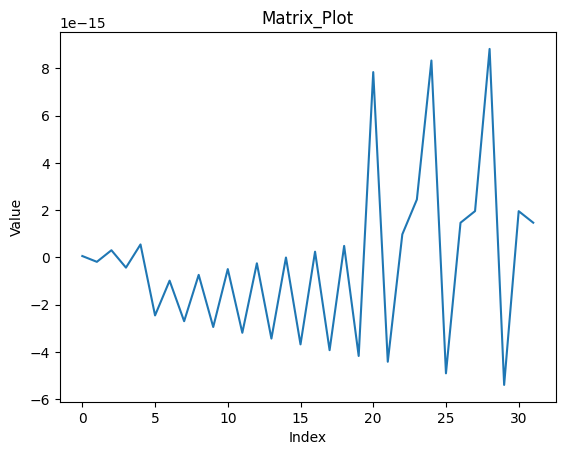

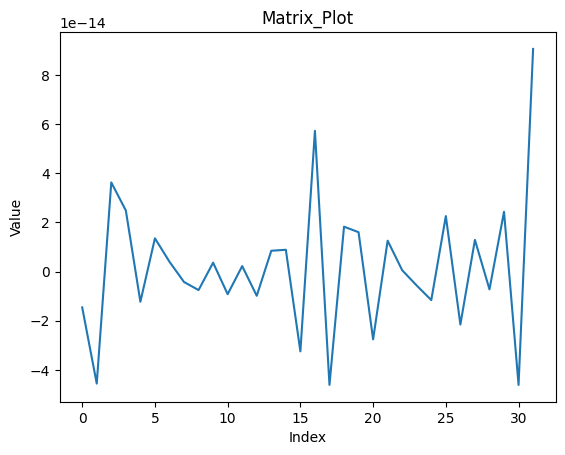


------------------------
* test-30
    boundary condition : from neumann to neumann
    mode               : 33
    actual mode        : [31]
    Result             : [FAILED] Resolution N might be too low.


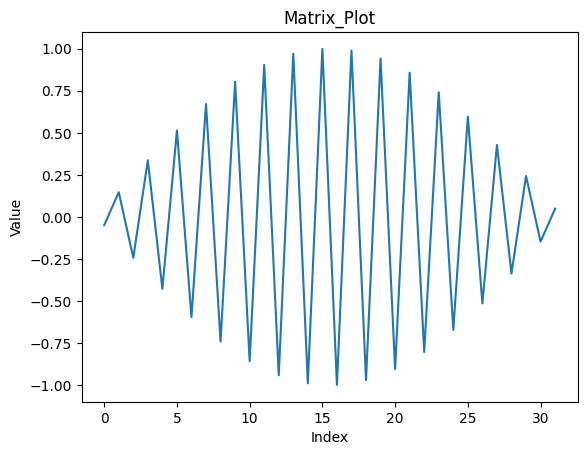

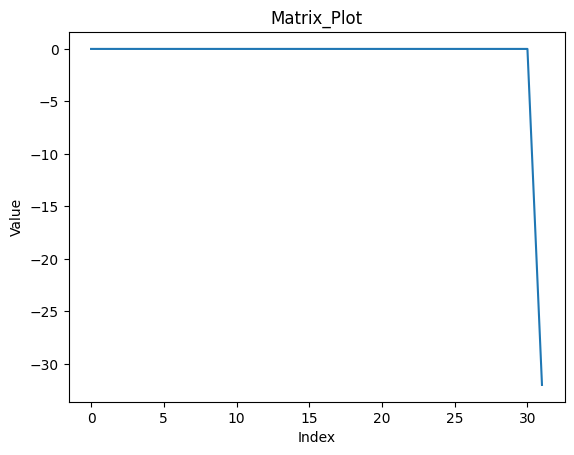

In [104]:
test_id = 0
for bc_from in TEST_BC:
    for bc_to in TEST_BC:
        for mode in TEST_MODE:
            if bc_from == 0 and bc_to != 0: continue
            if bc_to == 0 and bc_from != 0: continue
            test_id = test_id + 1
            axis_value, f_in = generate_data(DIM, [bc_from, bc_to] * DIM, N, L, [mode]*DIM)
            f_spectrum, sl = init_sturm_liouville_solver(f_in, [bc_from, bc_to] * DIM, L)
            sl.transform_to_spectrum()
            f_spectrum  = np.real(f_spectrum)
            actual_mode = get_mode(bc_from, bc_to,f_spectrum, math.prod(N)//2)
            print("\n------------------------")
            print(f"* test-{test_id}")
            print(f"    boundary condition : from {sl_solver.boundary_name[bc_from]} to {sl_solver.boundary_name[bc_to]}")
            print(f"    mode               : {mode}")
            print(f"    actual mode        : {actual_mode}")
            if mode in actual_mode:
                print("    Result             : [PASSED] Sampling theorem satisfied.")
            else:
                print("    Result             : [FAILED] Resolution N might be too low.")
            display_image(f_in)
            display_image(f_spectrum)
